# Session 23: ML Capstone Project - Customer Churn Prediction
### Duration: ~2.5-3 Hours

---

## Capstone Goal
Build an end-to-end machine learning project using a famous real customer dataset: **IBM Telco Customer Churn**.

Business question:
> Can we identify customers who are likely to leave, understand why they churn, and group customers into useful retention segments?

## What This Capstone Reviews
- Python project workflow and reproducible notebooks
- pandas data loading, inspection, cleaning, grouping, and feature engineering
- NumPy for numeric thinking and reproducibility
- Matplotlib and seaborn for exploratory data analysis
- Descriptive statistics, correlation, and class imbalance checks
- Train/test split and leakage-aware preprocessing
- scikit-learn pipelines with scaling and one-hot encoding
- Baseline models, stronger models, and hyperparameter tuning
- Evaluation beyond accuracy: precision, recall, F1, ROC-AUC, confusion matrix
- Unsupervised learning with KMeans for customer segmentation
- Saving models and project artifacts with joblib and CSV files

## Dataset
The notebook loads the IBM Telco Customer Churn CSV from IBM's public GitHub repository. It contains customer demographics, services, contract details, billing information, and whether the customer churned.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')

RANDOM_STATE = 42
DATA_URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
OUTPUT_DIR = Path('capstone_artifacts')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Environment ready.')

Environment ready.


---
## 1. Load the Real Customer Dataset

A capstone should start with a clear understanding of the raw data. We will inspect rows, columns, data types, missing values, and the target variable.

In [2]:
raw = pd.read_csv(DATA_URL)

print('Raw shape:', raw.shape)
print('\nColumns:')
print(raw.columns.tolist())

raw.head()

Raw shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print('Data types and non-null counts:')
raw.info()

print('\nTarget distribution:')
print(raw['Churn'].value_counts())

print('\nTarget percentage:')
print((raw['Churn'].value_counts(normalize=True) * 100).round(2))

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  704

---
## 2. Data Quality Audit and Cleaning

Important issues in this dataset:
- `customerID` is an identifier, not a predictive feature.
- `TotalCharges` looks numeric, but is stored as text because some rows contain blank values.
- `SeniorCitizen` is stored as 0/1, but behaves like a categorical customer attribute.
- The target `Churn` must be mapped to 0/1 for modeling.

In [4]:
df = raw.copy()

# Convert text charges to numeric. Blank strings become NaN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Make binary/categorical meanings clearer for analysis.
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
df['ChurnFlag'] = df['Churn'].map({'No': 0, 'Yes': 1})

quality_report = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(3),
    'unique_values': df.nunique(),
}).sort_values('missing_count', ascending=False)

quality_report

,dtype,missing_count,missing_pct,unique_values
TotalCharges,float64,11,0.156,6530
customerID,str,0,0.000,7043
SeniorCitizen,str,0,0.000,2
Partner,str,0,0.000,2
Dependents,str,0,0.000,2
gender,str,0,0.000,2
tenure,int64,0,0.000,73
PhoneService,str,0,0.000,2
InternetService,str,0,0.000,3
MultipleLines,str,0,0.000,3


In [5]:
# Tenure is 0 for a small number of new customers; their TotalCharges are missing.
# For this project, filling missing TotalCharges with 0 is a reasonable business assumption.
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Add a few interpretable features that a business stakeholder can understand.
df['AvgMonthlyChargesSoFar'] = np.where(
    df['tenure'] > 0,
    df['TotalCharges'] / df['tenure'],
    0,
)

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months'],
)

df['HighMonthlyCharges'] = np.where(
    df['MonthlyCharges'] >= df['MonthlyCharges'].median(),
    'Yes',
    'No',
)

print('Cleaned shape:', df.shape)
print('Remaining missing values:', int(df.isna().sum().sum()))
df.head()

Cleaned shape: (7043, 25)
Remaining missing values: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag,AvgMonthlyChargesSoFar,TenureGroup,HighMonthlyCharges
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,29.850000,0-12 months,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,0,55.573529,25-48 months,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,54.075000,0-12 months,No
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,40.905556,25-48 months,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,75.825000,0-12 months,Yes


---
## 3. Exploratory Data Analysis

Before modeling, we need to understand the business pattern. We will compare churn rates across contracts, internet service, payment methods, tenure, and charges.

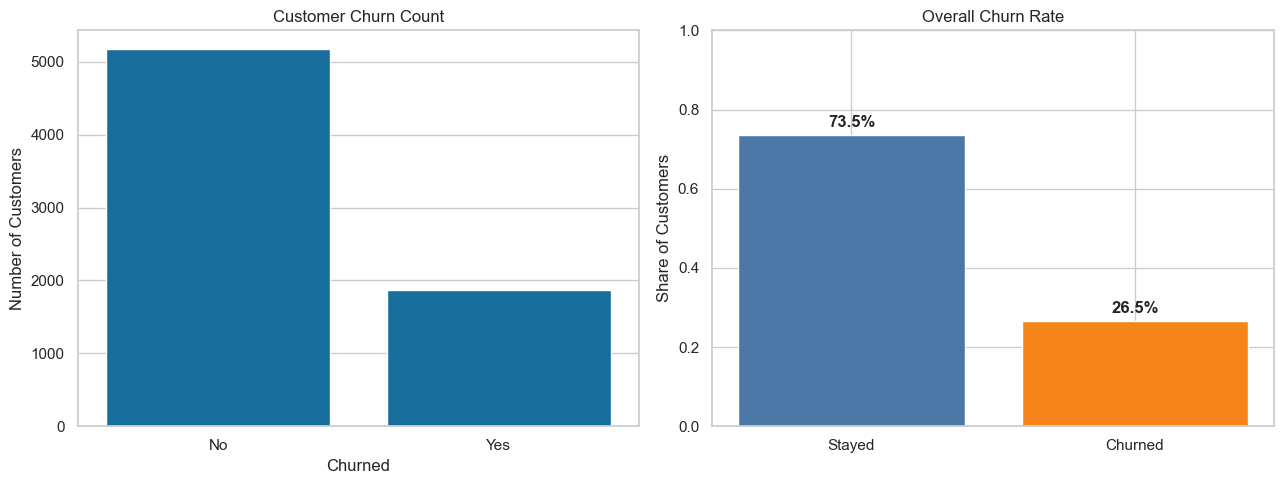

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x='Churn', ax=axes[0])
axes[0].set_title('Customer Churn Count')
axes[0].set_xlabel('Churned')
axes[0].set_ylabel('Number of Customers')

churn_rate = df['ChurnFlag'].mean()
axes[1].bar(['Stayed', 'Churned'], [1 - churn_rate, churn_rate], color=['#4C78A8', '#F58518'])
axes[1].set_title('Overall Churn Rate')
axes[1].set_ylabel('Share of Customers')
axes[1].set_ylim(0, 1)

for i, value in enumerate([1 - churn_rate, churn_rate]):
    axes[1].text(i, value + 0.02, f'{value:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

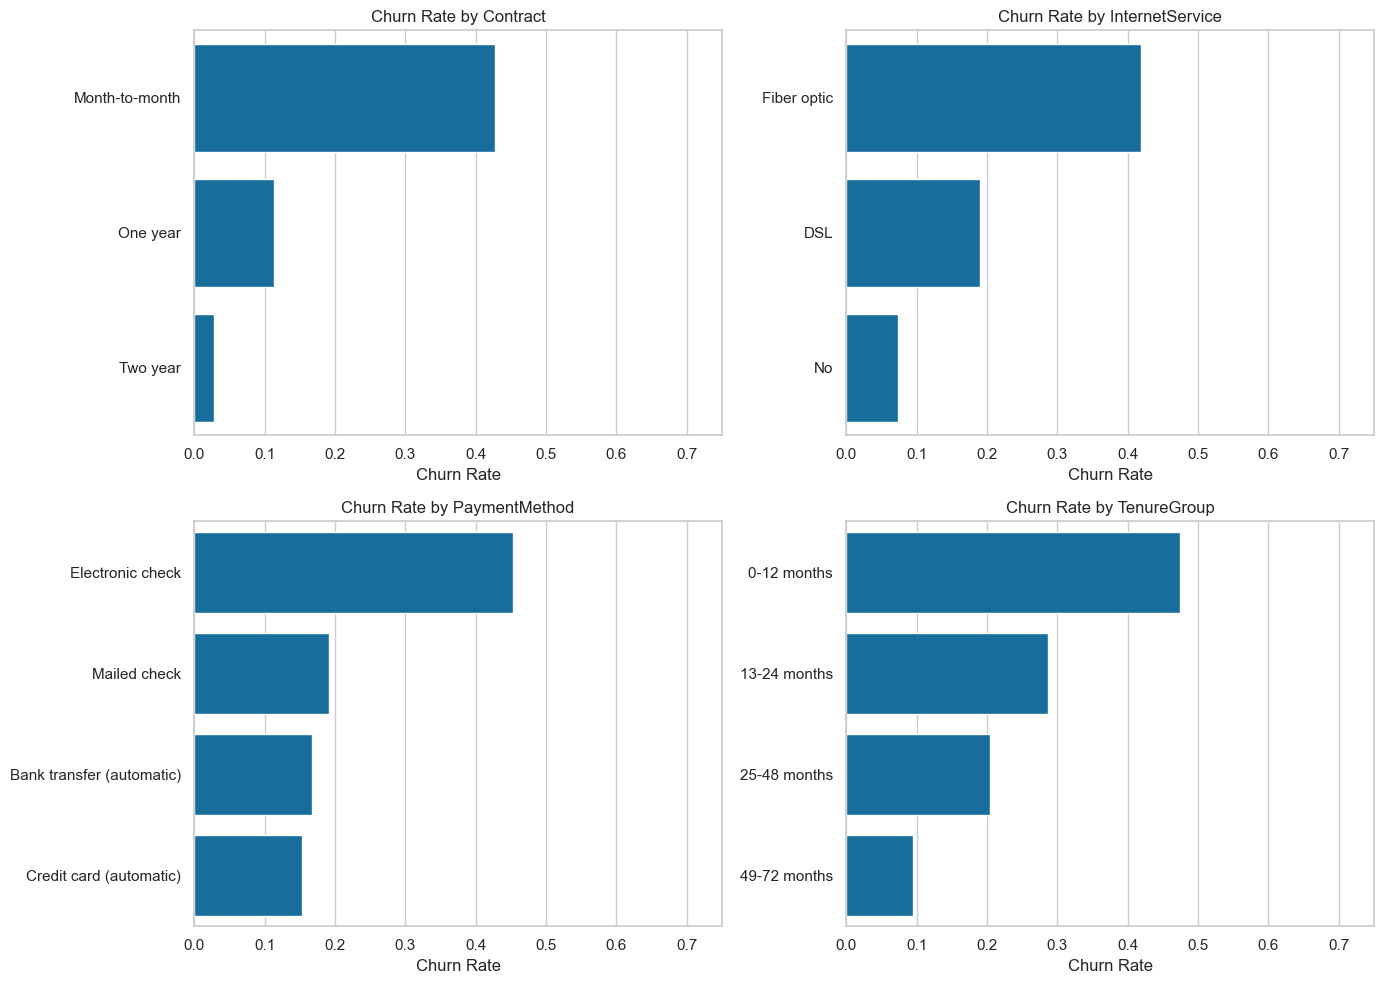

In [7]:
def plot_churn_rate(category_col, ax):
    rates = (
        df.groupby(category_col)['ChurnFlag']
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    sns.barplot(data=rates, x='ChurnFlag', y=category_col, ax=ax)
    ax.set_title(f'Churn Rate by {category_col}')
    ax.set_xlabel('Churn Rate')
    ax.set_ylabel('')
    ax.set_xlim(0, max(0.75, rates['ChurnFlag'].max() + 0.05))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for col, ax in zip(['Contract', 'InternetService', 'PaymentMethod', 'TenureGroup'], axes.ravel()):
    plot_churn_rate(col, ax)

plt.tight_layout()
plt.show()

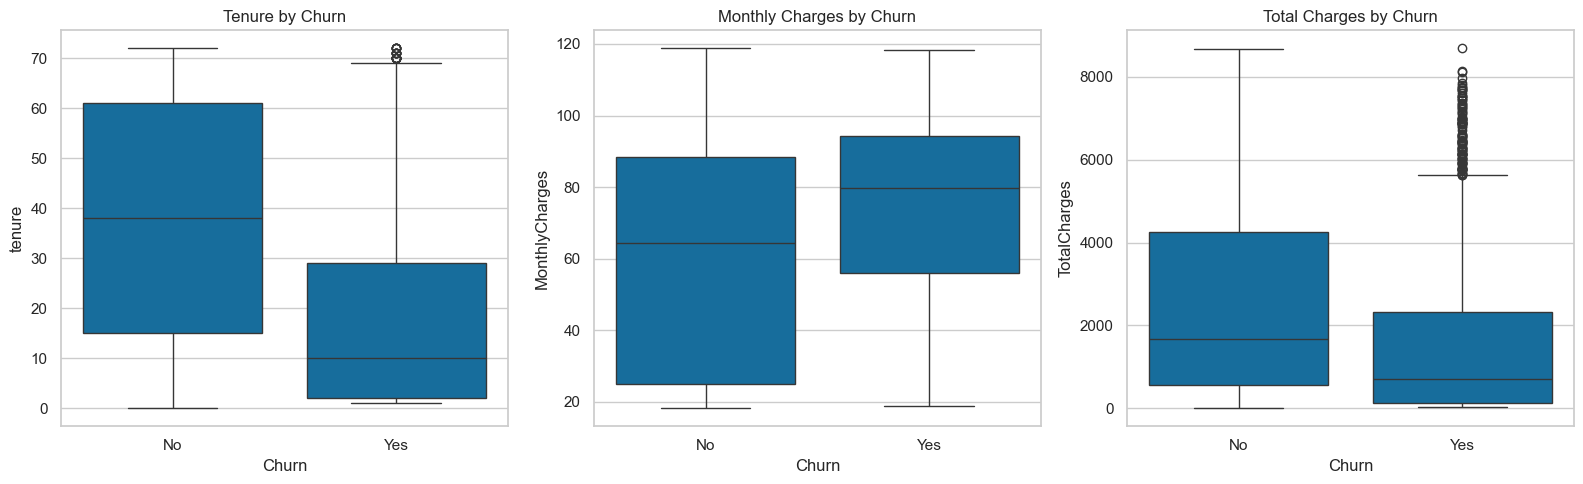

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0])
axes[0].set_title('Tenure by Churn')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_title('Monthly Charges by Churn')

sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[2])
axes[2].set_title('Total Charges by Churn')

plt.tight_layout()
plt.show()

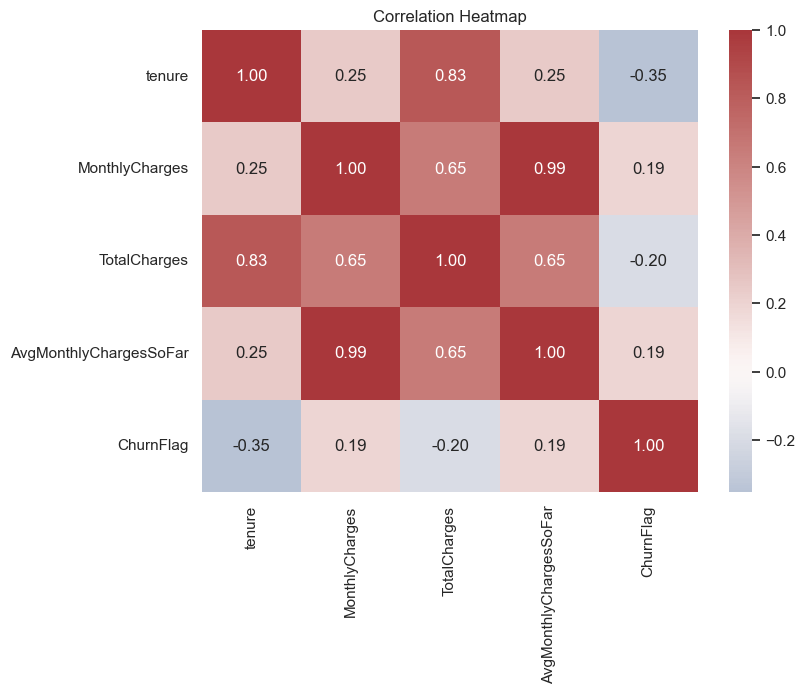

In [9]:
numeric_for_corr = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyChargesSoFar', 'ChurnFlag']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_for_corr].corr(), annot=True, cmap='vlag', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

---
## 4. Define the ML Problem

We will predict `ChurnFlag` from customer attributes. The model should be useful for retention planning, so recall and ROC-AUC matter alongside accuracy.

We split before fitting preprocessing steps to avoid data leakage.

In [10]:
target = 'ChurnFlag'
drop_cols = ['customerID', 'Churn', target]

X = df.drop(columns=drop_cols)
y = df[target]

numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])
print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)
print('\nTrain churn rate:', round(y_train.mean(), 4))
print('Test churn rate:', round(y_test.mean(), 4))

Training rows: 5282
Test rows: 1761
Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyChargesSoFar']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup', 'HighMonthlyCharges']

Train churn rate: 0.2654
Test churn rate: 0.2652


In [11]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

print('Preprocessing pipeline ready.')

Preprocessing pipeline ready.


---
## 5. Baseline and First Model

A strong ML project compares against a simple baseline. If a model cannot beat a simple rule, it is not useful yet.

In [12]:
def evaluate_classifier(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
    }

baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent')),
])

log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
])

baseline.fit(X_train, y_train)
log_reg.fit(X_train, y_train)

baseline_result = evaluate_classifier('Baseline: majority class', baseline, X_test, y_test)
log_reg_result = evaluate_classifier('Logistic Regression', log_reg, X_test, y_test)

pd.DataFrame([baseline_result, log_reg_result]).round(4)

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline: majority class,0.7348,0.0000,0.0000,0.0000,0.5000
1,Logistic Regression,0.7433,0.5103,0.7944,0.6214,0.8454


              precision    recall  f1-score   support

      Stayed      0.907     0.725     0.806      1294
     Churned      0.510     0.794     0.621       467

    accuracy                          0.743      1761
   macro avg      0.709     0.760     0.714      1761
weighted avg      0.802     0.743     0.757      1761



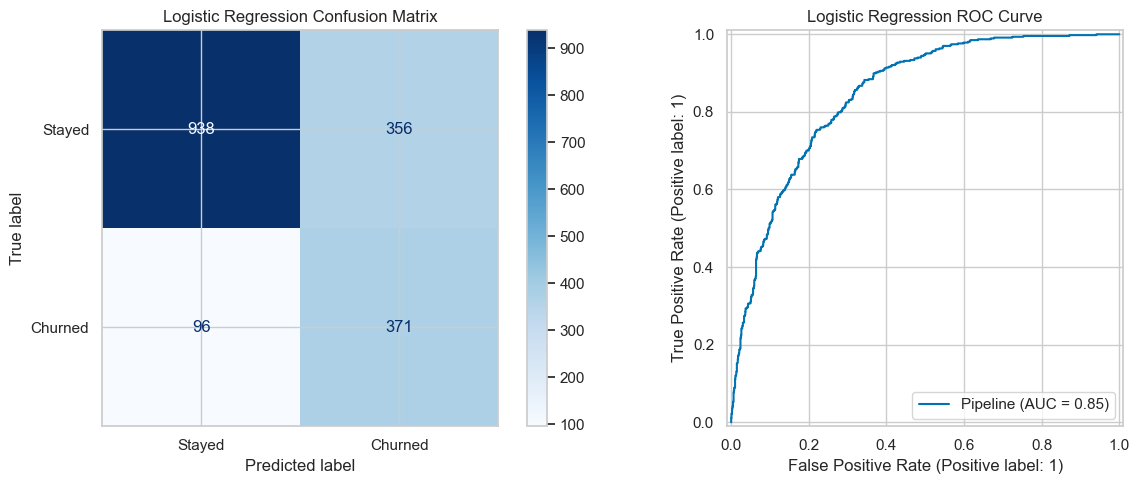

In [13]:
y_pred_log = log_reg.predict(X_test)

print(classification_report(y_test, y_pred_log, target_names=['Stayed', 'Churned'], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_estimator(
    log_reg,
    X_test,
    y_test,
    display_labels=['Stayed', 'Churned'],
    cmap='Blues',
    ax=axes[0],
)
axes[0].set_title('Logistic Regression Confusion Matrix')

RocCurveDisplay.from_estimator(log_reg, X_test, y_test, ax=axes[1])
axes[1].set_title('Logistic Regression ROC Curve')

plt.tight_layout()
plt.show()

---
## 6. Try a Stronger Model and Tune Hyperparameters

Now we try a Random Forest. It can capture non-linear relationships, but we still keep preprocessing inside the pipeline.

In [14]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=1,
    )),
])

param_grid = {
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [6, 10, None],
    'classifier__min_samples_leaf': [1, 3, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=1,
    verbose=0,
)

search.fit(X_train, y_train)

print('Best parameters:')
print(search.best_params_)
print('\nBest CV ROC-AUC:', round(search.best_score_, 4))

best_rf = search.best_estimator_

Best parameters:
{'classifier__max_depth': 6, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}

Best CV ROC-AUC: 0.8458


In [15]:
rf_result = evaluate_classifier('Tuned Random Forest', best_rf, X_test, y_test)
results = pd.DataFrame([baseline_result, log_reg_result, rf_result]).sort_values('roc_auc', ascending=False)
results.round(4)

,model,accuracy,precision,recall,f1,roc_auc
2,Tuned Random Forest,0.7621,0.5348,0.7901,0.6379,0.8458
1,Logistic Regression,0.7433,0.5103,0.7944,0.6214,0.8454
0,Baseline: majority class,0.7348,0.0000,0.0000,0.0000,0.5000


              precision    recall  f1-score   support

      Stayed      0.908     0.752     0.823      1294
     Churned      0.535     0.790     0.638       467

    accuracy                          0.762      1761
   macro avg      0.722     0.771     0.730      1761
weighted avg      0.809     0.762     0.774      1761



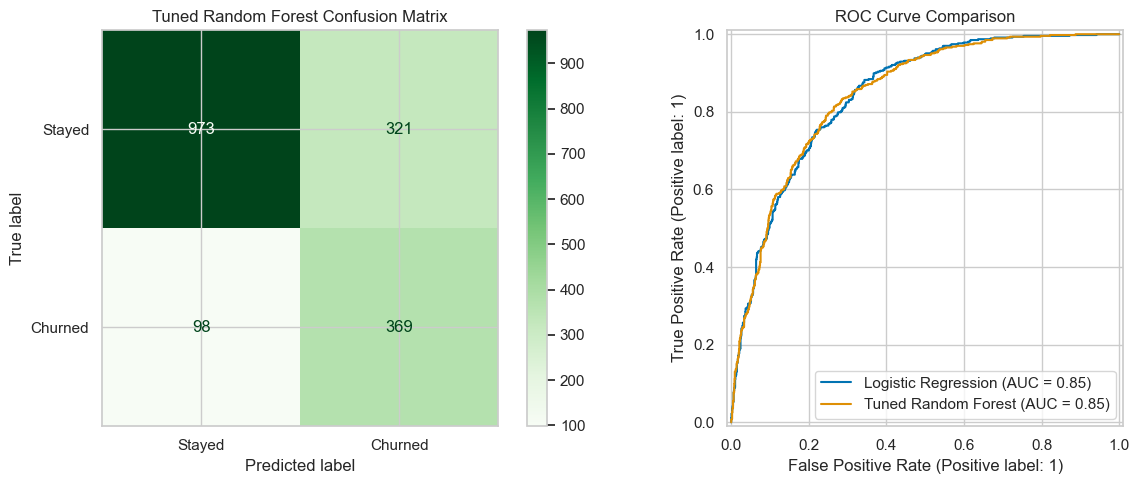

In [16]:
y_pred_rf = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Churned'], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    display_labels=['Stayed', 'Churned'],
    cmap='Greens',
    ax=axes[0],
)
axes[0].set_title('Tuned Random Forest Confusion Matrix')

RocCurveDisplay.from_estimator(log_reg, X_test, y_test, ax=axes[1], name='Logistic Regression')
RocCurveDisplay.from_estimator(best_rf, X_test, y_test, ax=axes[1], name='Tuned Random Forest')
axes[1].set_title('ROC Curve Comparison')

plt.tight_layout()
plt.show()

---
## 7. Interpret Important Drivers

A capstone should explain the model, not only report a score. Random Forest feature importances help identify influential churn signals after preprocessing.

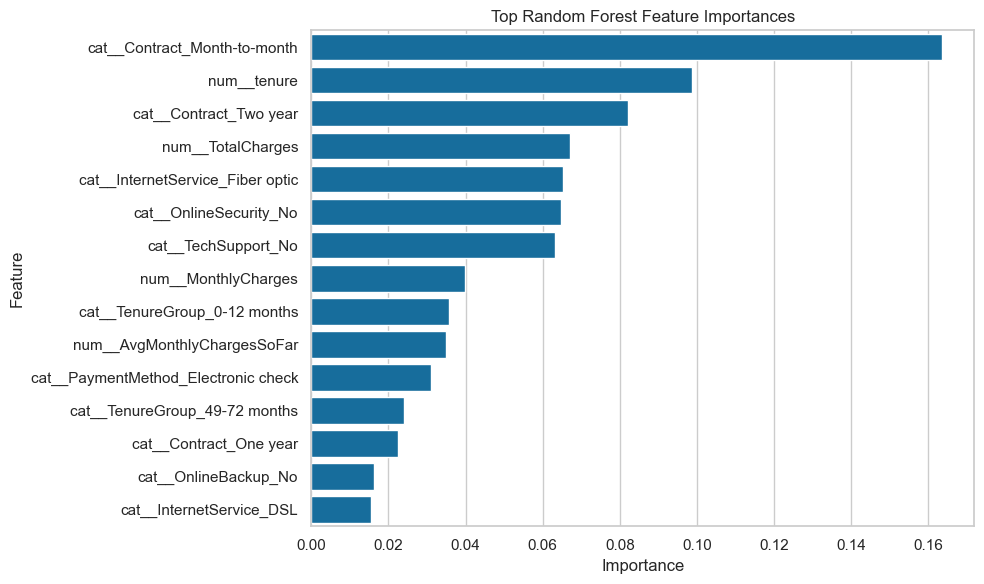

,feature,importance
38,cat__Contract_Month-to-month,0.163675
0,num__tenure,0.098719
40,cat__Contract_Two year,0.082018
2,num__TotalCharges,0.067185
18,cat__InternetService_Fiber optic,0.065152
20,cat__OnlineSecurity_No,0.064616
29,cat__TechSupport_No,0.063286
1,num__MonthlyCharges,0.039860
47,cat__TenureGroup_0-12 months,0.035802
3,num__AvgMonthlyChargesSoFar,0.034805


In [17]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['classifier'].feature_importances_

importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Top Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

importance_df

---
## 8. Customer Segmentation with Clustering

Prediction answers: "Who might churn?"  
Clustering answers: "What kinds of customers do we have?"

We will cluster customers using numeric behavior features, then compare churn rate by segment.

In [18]:
segment_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyChargesSoFar']
segment_df = df[segment_features].copy()

segment_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)),
])

df['Segment'] = segment_pipeline.fit_predict(segment_df)

segment_summary = (
    df.groupby('Segment')
    .agg(
        customers=('customerID', 'count'),
        churn_rate=('ChurnFlag', 'mean'),
        avg_tenure=('tenure', 'mean'),
        avg_monthly_charges=('MonthlyCharges', 'mean'),
        avg_total_charges=('TotalCharges', 'mean'),
    )
    .round(2)
    .sort_values('churn_rate', ascending=False)
)

segment_summary

,customers,churn_rate,avg_tenure,avg_monthly_charges,avg_total_charges
Segment,,,,,
1,2297,0.48,15.41,80.22,1238.01
3,1724,0.24,10.92,31.36,318.08
2,1906,0.16,59.09,93.78,5538.09
0,1116,0.05,54.80,34.98,1889.32


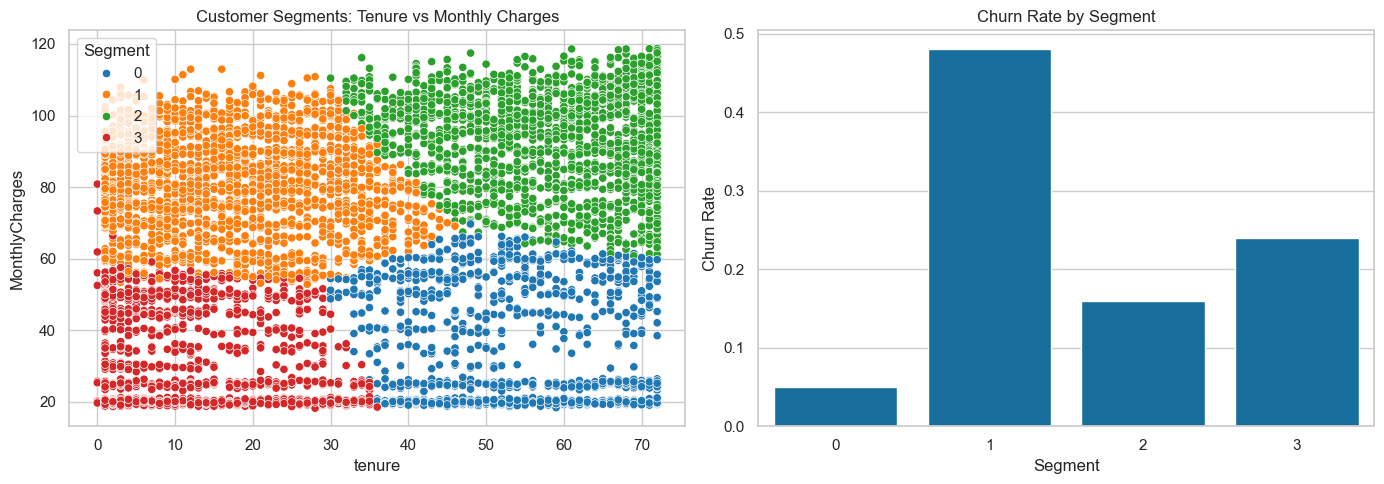

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Segment',
    palette='tab10',
    ax=axes[0],
)
axes[0].set_title('Customer Segments: Tenure vs Monthly Charges')

sns.barplot(
    data=segment_summary.reset_index(),
    x='Segment',
    y='churn_rate',
    ax=axes[1],
)
axes[1].set_title('Churn Rate by Segment')
axes[1].set_ylabel('Churn Rate')

plt.tight_layout()
plt.show()

---
## 9. Make Business-Friendly Predictions

A retention team usually needs a ranked list, not just a model score. Here we create a small action table showing high-risk customers from the test set.

In [20]:
test_customers = raw.loc[X_test.index, ['customerID']].copy()
test_customers['actual_churn'] = y_test.map({0: 'No', 1: 'Yes'}).values
test_customers['predicted_churn_probability'] = best_rf.predict_proba(X_test)[:, 1]
test_customers['predicted_churn'] = np.where(test_customers['predicted_churn_probability'] >= 0.5, 'Yes', 'No')

risk_table = (
    test_customers
    .join(X_test[['Contract', 'tenure', 'MonthlyCharges', 'InternetService', 'PaymentMethod']])
    .sort_values('predicted_churn_probability', ascending=False)
)

risk_table.head(15)

,customerID,actual_churn,predicted_churn_probability,predicted_churn,Contract,tenure,MonthlyCharges,InternetService,PaymentMethod
3380,5178-LMXOP,Yes,0.902601,Yes,Month-to-month,1,95.10,Fiber optic,Electronic check
4585,1069-XAIEM,Yes,0.899386,Yes,Month-to-month,1,85.05,Fiber optic,Electronic check
6866,0295-PPHDO,Yes,0.897756,Yes,Month-to-month,1,95.45,Fiber optic,Electronic check
5474,4912-PIGUY,No,0.895134,Yes,Month-to-month,1,84.60,Fiber optic,Electronic check
3727,9057-SIHCH,Yes,0.894389,Yes,Month-to-month,3,96.60,Fiber optic,Electronic check
3346,2545-EBUPK,No,0.892175,Yes,Month-to-month,2,84.05,Fiber optic,Electronic check
4039,8161-QYMTT,No,0.890641,Yes,Month-to-month,7,94.10,Fiber optic,Electronic check
933,4750-ZRXIU,Yes,0.889664,Yes,Month-to-month,4,84.60,Fiber optic,Electronic check
642,0970-ETWGE,Yes,0.889636,Yes,Month-to-month,1,89.55,Fiber optic,Electronic check
2631,6861-XWTWQ,Yes,0.888728,Yes,Month-to-month,7,99.25,Fiber optic,Electronic check


In [21]:
# A simple threshold experiment: what happens if the business wants to contact the riskiest 20%?
contact_rate = 0.20
threshold = risk_table['predicted_churn_probability'].quantile(1 - contact_rate)

campaign = risk_table.assign(contact_customer=risk_table['predicted_churn_probability'] >= threshold)

campaign_summary = pd.DataFrame({
    'customers_in_test': [len(campaign)],
    'customers_contacted': [campaign['contact_customer'].sum()],
    'contact_rate': [campaign['contact_customer'].mean()],
    'churners_captured': [campaign.loc[campaign['contact_customer'], 'actual_churn'].eq('Yes').sum()],
    'precision_among_contacted': [campaign.loc[campaign['contact_customer'], 'actual_churn'].eq('Yes').mean()],
})

campaign_summary.round(4)

,customers_in_test,customers_contacted,contact_rate,churners_captured,precision_among_contacted
0,1761,353,0.2005,232,0.6572


---
## 10. Save Final Artifacts

The final project should leave reusable files behind: trained model, clustering pipeline, metrics, feature importance, and ranked customer risk table.

In [22]:
model_path = OUTPUT_DIR / 'telco_churn_model.joblib'
segment_path = OUTPUT_DIR / 'telco_customer_segmentation.joblib'
metrics_path = OUTPUT_DIR / 'telco_model_metrics.csv'
importance_path = OUTPUT_DIR / 'telco_feature_importance.csv'
risk_path = OUTPUT_DIR / 'telco_customer_risk_table.csv'
segment_summary_path = OUTPUT_DIR / 'telco_segment_summary.csv'

results.to_csv(metrics_path, index=False)
importance_df.to_csv(importance_path, index=False)
risk_table.to_csv(risk_path, index=False)
segment_summary.to_csv(segment_summary_path)
dump(best_rf, model_path)
dump(segment_pipeline, segment_path)

print('Saved model:', model_path)
print('Saved segmentation pipeline:', segment_path)
print('Saved metrics:', metrics_path)
print('Saved feature importance:', importance_path)
print('Saved risk table:', risk_path)
print('Saved segment summary:', segment_summary_path)

Saved model: capstone_artifacts\telco_churn_model.joblib
Saved segmentation pipeline: capstone_artifacts\telco_customer_segmentation.joblib
Saved metrics: capstone_artifacts\telco_model_metrics.csv
Saved feature importance: capstone_artifacts\telco_feature_importance.csv
Saved risk table: capstone_artifacts\telco_customer_risk_table.csv
Saved segment summary: capstone_artifacts\telco_segment_summary.csv


---
## 11. Final Capstone Reflection

### What We Learned
- Real customer data needs careful type conversion and missing-value handling.
- Class imbalance makes accuracy incomplete; recall, F1, and ROC-AUC tell a richer story.
- Pipelines keep preprocessing and modeling reproducible.
- Hyperparameter tuning should optimize the metric that matches the business goal.
- Segmentation complements prediction by describing customer groups.
- A useful ML project produces artifacts that other people can reuse.

### Suggested Presentation Structure
1. State the business problem: reducing customer churn.
2. Explain the dataset and target variable.
3. Show the biggest churn patterns from EDA.
4. Compare baseline, logistic regression, and tuned random forest.
5. Discuss model tradeoffs: recall vs precision.
6. Present the highest-risk customer table and customer segments.
7. Recommend next steps: better retention cost data, time-based validation, and controlled campaign testing.

### Optional Extensions
- Tune the prediction threshold for a specific retention budget.
- Compare more models, such as SVM or gradient boosting.
- Build a small Streamlit app for churn scoring.
- Track model performance over time as new customer data arrives.